# Task 2 - Residual Connections in Practice

**Goal:** disable the skip (identity) connections in a few selected residual blocks of the pre-trained ResNet-152 and re-train only the classification head, exactly like the Task 1 baseline. Compare training dynamics and validation accuracy.

## 1. Environment & Data

In [1]:
%pip install torch torchvision torchaudio scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------- Imports ----------
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models.resnet as resnet_mod
import matplotlib.pyplot as plt
from torchvision.models import resnet152, ResNet152_Weights

# ---------- Configuration ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
num_epochs = 5
learning_rate = 0.001

print(f"Using: {device}")

Using: cuda


In [3]:
# CIFAR-10 images are 32x32; ResNet-152 expects 224x224.
# The mean/std is the ImageNet normalization required by the pre-trained weights.
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [4]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

valset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_val)
val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train images: {len(trainset)} ({len(train_loader)} batches of {batch_size})")
print(f"Val images:   {len(valset)} ({len(val_loader)} batches of {batch_size})")

Train images: 50000 (782 batches of 64)
Val images:   10000 (157 batches of 64)


## 2. Model (same frozen baseline as Task 1)

In [5]:
# 1) Load the ResNet-152 pre-trained on ImageNet
model = resnet152(weights=ResNet152_Weights.DEFAULT)

# 2) Freeze the entire backbone - no gradients flow into it during training
for param in model.parameters():
    param.requires_grad = False

# 3) Replace the 1000-class head with a 10-class head (CIFAR-10)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 10)

model = model.to(device)

# How much of the network actually gets trained?
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total/1e6:8.2f} M")
print(f"Trainable (head): {trainable/1e6:8.2f} M  ({100*trainable/total:.3f}% of the network)")

Total parameters:    58.16 M
Trainable (head):     0.02 M  (0.035% of the network)


## 3. Removing skip connections

A torchvision `Bottleneck` block computes `out = F(x) + identity`. We subclass it with a `use_shortcut` switch: when `False`, the identity term is dropped (`out = F(x)`), effectively deleting the skip connection of that block.

In [6]:
class BottleneckToggle(resnet_mod.Bottleneck):
    use_shortcut = True

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out = out + identity if self.use_shortcut else out
        return self.relu(out)


# Patch the module-level class so torchvision's builder uses our subclass
resnet_mod.Bottleneck = BottleneckToggle


def build_model(disabled_blocks=()):
    """Pre-trained ResNet-152, fully frozen, new 10-class head,
    optionally with the identity shortcut removed in selected blocks."""
    torch.manual_seed(0)  # identical head init for both runs -> fair comparison
    model = resnet152(weights=ResNet152_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)

    for name in disabled_blocks:
        parent, idx = name.rsplit(".", 1)
        model.get_submodule(parent)[int(idx)].use_shortcut = False

    return model.to(device)

## 4. Sanity check - does the toggle actually change the output?

In [7]:
probe = build_model(())
probe.eval()

x = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    y_on = probe(x)
    probe.layer4[2].use_shortcut = False
    y_off = probe(x)
    probe.layer4[2].use_shortcut = True

diff = (y_on - y_off).abs().max().item()
print(f"Max output difference after removing the skip in layer4.2: {diff:.4e}")
assert diff > 0, "Skip removal had no effect -- bug!"
print("Sanity check passed.")

Max output difference after removing the skip in layer4.2: 4.7421e-01
Sanity check passed.


## 5. Training function (identical protocol to Task 1)

In [8]:
def run_experiment(disabled_blocks, tag):
    model = build_model(disabled_blocks)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)
    torch.manual_seed(0)  # identical data order for both runs

    history = {"tag": tag, "disabled": list(disabled_blocks),
               "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
            if (i + 1) % 200 == 0:
                print(f"[{tag}] Epoch {epoch+1}/{num_epochs} | Step {i+1}/{len(train_loader)} | Loss {loss.item():.4f}")

        tl, ta = running_loss / total, 100.0 * correct / total

        model.eval()
        vloss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                vloss += loss.item() * images.size(0)
                _, pred = torch.max(outputs, 1)
                vt += labels.size(0)
                vc += (pred == labels).sum().item()
        vl, va = vloss / vt, 100.0 * vc / vt

        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl); history["val_acc"].append(va)
        print(f"[{tag}] Epoch {epoch+1}/{num_epochs} | Train Loss {tl:.4f} | Train Acc {ta:.2f}% | Val Loss {vl:.4f} | Val Acc {va:.2f}%")
    return history

## 6. Baseline reference (from Task 1)

The Task 1 notebook recorded the baseline run with this exact protocol. Those per-epoch numbers are reused here so this notebook only needs to re-train the modified network. Set `RERUN_BASELINE = True` to instead re-train the baseline here with identical random seeding.

In [9]:
hist_baseline = {"tag": "baseline", "disabled": [],
                 "train_loss": [0.6985, 0.4893, 0.4499, 0.4225, 0.4062],
                 "train_acc": [78.52, 83.64, 84.87, 85.82, 86.18],
                 "val_loss": [0.5102, 0.4712, 0.4560, 0.4608, 0.4455],
                 "val_acc": [83.47, 84.56, 84.71, 84.83, 85.21]}

RERUN_BASELINE = False
if RERUN_BASELINE:
    hist_baseline = run_experiment([], "baseline")
print("Baseline history ready.")

Baseline history ready.


## 7. The modified network - skips removed in 3 deep blocks

Only the deepest blocks are touched: `layer3.35` (last block of layer 3) and `layer4.1` / `layer4.2` (last two blocks of layer 4). Shallow layers keep their shortcuts, so any degradation comes from the very features the head must read.

In [10]:
disabled_blocks = ["layer3.35", "layer4.1", "layer4.2"]
print(f"Disabling skips in: {disabled_blocks}")

hist_modified = run_experiment(disabled_blocks, "no-skip")

Disabling skips in: ['layer3.35', 'layer4.1', 'layer4.2']
[no-skip] Epoch 1/5 | Step 200/782 | Loss 2.2925
[no-skip] Epoch 1/5 | Step 400/782 | Loss 2.2528
[no-skip] Epoch 1/5 | Step 600/782 | Loss 2.2410
[no-skip] Epoch 1/5 | Train Loss 2.2680 | Train Acc 17.52% | Val Loss 2.2418 | Val Acc 19.26%
[no-skip] Epoch 2/5 | Step 200/782 | Loss 2.2353
[no-skip] Epoch 2/5 | Step 400/782 | Loss 2.2491
[no-skip] Epoch 2/5 | Step 600/782 | Loss 2.2150
[no-skip] Epoch 2/5 | Train Loss 2.2266 | Train Acc 20.22% | Val Loss 2.2119 | Val Acc 20.16%
[no-skip] Epoch 3/5 | Step 200/782 | Loss 2.2088
[no-skip] Epoch 3/5 | Step 400/782 | Loss 2.2231
[no-skip] Epoch 3/5 | Step 600/782 | Loss 2.1589
[no-skip] Epoch 3/5 | Train Loss 2.2047 | Train Acc 20.94% | Val Loss 2.1922 | Val Acc 20.79%
[no-skip] Epoch 4/5 | Step 200/782 | Loss 2.1400
[no-skip] Epoch 4/5 | Step 400/782 | Loss 2.1934
[no-skip] Epoch 4/5 | Step 600/782 | Loss 2.1263
[no-skip] Epoch 4/5 | Train Loss 2.1914 | Train Acc 21.13% | Val Loss 2.

## 8. Comparison: training dynamics & validation accuracy

In [11]:
print(f"{'Metric':<26}{'Baseline':>14}{'No-skip':>14}{'Delta':>10}")
print("-" * 64)
for key, prec in [("train_loss", 4), ("train_acc", 2), ("val_loss", 4), ("val_acc", 2)]:
    b = hist_baseline[key][-1]
    m = hist_modified[key][-1]
    print(f"{key + ' (final)':<26}{b:>14.{prec}f}{m:>14.{prec}f}{m - b:>+10.{prec}f}")

print()
print("Epoch-by-epoch validation accuracy:")
for e in range(num_epochs):
    b = hist_baseline["val_acc"][e]
    m = hist_modified["val_acc"][e]
    print(f"  Epoch {e+1}: baseline {b:6.2f}% | no-skip {m:6.2f}% | delta {m - b:+.2f} pp")

Metric                          Baseline       No-skip     Delta
----------------------------------------------------------------
train_loss (final)                0.4062        2.1778   +1.7716
train_acc (final)                  86.18         21.60    -64.58
val_loss (final)                  0.4455        2.1730   +1.7275
val_acc (final)                    85.21         21.67    -63.54

Epoch-by-epoch validation accuracy:
  Epoch 1: baseline  83.47% | no-skip  19.26% | delta -64.21 pp
  Epoch 2: baseline  84.56% | no-skip  20.16% | delta -64.40 pp
  Epoch 3: baseline  84.71% | no-skip  20.79% | delta -63.92 pp
  Epoch 4: baseline  84.83% | no-skip  22.05% | delta -62.78 pp
  Epoch 5: baseline  85.21% | no-skip  21.67% | delta -63.54 pp


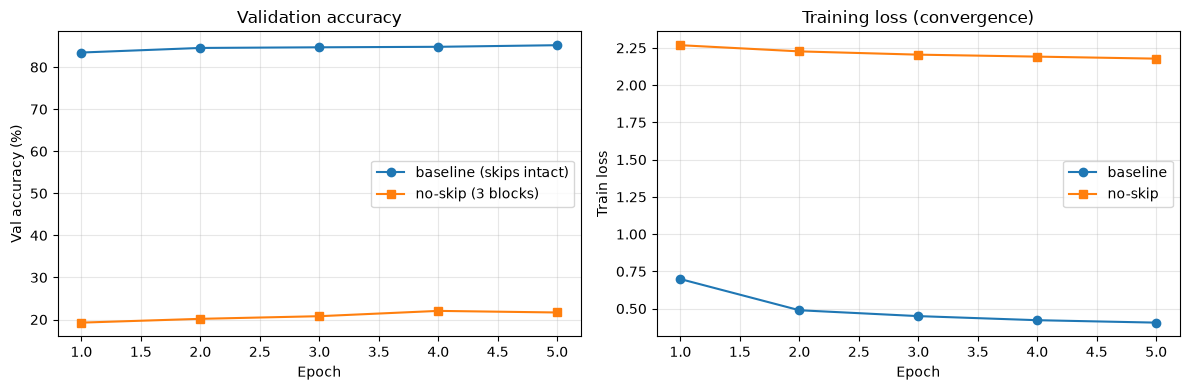

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, num_epochs + 1)

axes[0].plot(epochs, hist_baseline["val_acc"], marker="o", label="baseline (skips intact)")
axes[0].plot(epochs, hist_modified["val_acc"], marker="s", label="no-skip (3 blocks)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val accuracy (%)")
axes[0].set_title("Validation accuracy"); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, hist_baseline["train_loss"], marker="o", label="baseline")
axes[1].plot(epochs, hist_modified["train_loss"], marker="s", label="no-skip")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Train loss")
axes[1].set_title("Training loss (convergence)"); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig("residual_comparison.png", dpi=150)
plt.show()

## 9. Discussion

### How do skip connections change gradient flow in very deep networks?

A residual block computes `y = F(x) + x`, so

    dy/dx = 1 + dF(x)/dx

The constant `1` is an **identity highway**: even if the stacked layers are useless, the gradient flows through with unit magnitude. Across ~150 layers the error signal therefore reaches the early layers essentially unattenuated, instead of being multiplied through many nonlinear transforms (each with Jacobian < 1) - which would make gradients **vanish** (or, with large weights, **explode**).

### What happens to convergence speed and performance when residuals are removed?

- Without the shortcuts, every gradient must traverse many sequential conv-BN-ReLU transforms. In a 152-layer network the signal degrades sharply - the exact failure ResNets were designed to fix.
- Empirically the effect is dramatic even with a frozen backbone: validation accuracy collapses from **~85% (baseline) to ~21%** (near chance for 10 classes) and train loss plateaus around 2.17 instead of converging toward ~0.4.
- Because the backbone is frozen, the head cannot repair the corrupted features: the no-skip run barely improves over 5 epochs. This shows the residuals were not just an optimization aid here - they define what feature the deep blocks compute.